# KYA face identification demo - MLP neural network training, Leo transpilation, Aleo deployment

## Overview of steps
* 📦 Ensure Leo and Python library installation
* 🧑‍🔬 Load default Einstein images
* 📷 Capture your own face (optional)
* 📂 Load the dataset and extract the features
* ✂️ Split into a training and test dataset
* 🏋️ Train the model
* 📊 Evaluate the model
* 🔄 PCA feature transformation
* 🔁 Re-train and evaluate the model
* ⚙️🦁 Transpile to Leo
* ▶️ Test execution of the Leo program
* 🚀 Deploy the Leo program
* 💡 Extension ideas
* 🗣️ Discussion
* 📚 Further resources

## 📦 Ensure Leo and Python library installation
For this Jupyter notebook to run successfully, you need to ensure Leo and selected Python libraries are installed. If you haven't so done already, follow the instructions in the `README.md` file.

In [1]:
# ── Standard library ─────────────────────────────────────────
import os
from pathlib import Path
import random
import re
import shutil
import subprocess

# ── Third-party packages ─────────────────────────────────────
from PIL import Image
import face_recognition
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from zkml import LeoTranspiler

# ── Local application imports ────────────────────────────────
from helper import plot_confusion_matrix, plot_mlp_architecture, summarize_mlp

/Users/kp/dev/python-sdk2/zkml-research/kya_face/.venv/lib/python3.12/site-packages/face_recognition_models/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [2]:
MIN_LEO = (3, 0, 0)
leo_path = shutil.which("leo")
if leo_path is None:
    raise EnvironmentError(
        "Leo CLI not found. Install it first. See the README.md file or open https://github.com/ProvableHQ/leo"
    )

leo_raw = subprocess.check_output(["leo", "--version"], text=True).strip()
leo_ver = tuple(map(int, re.search(r"(\d+)\.(\d+)\.(\d+)", leo_raw).groups()))
print(f"Detected Leo version: {leo_raw}")
if leo_ver < MIN_LEO:
    raise EnvironmentError(
        f"Leo ≥ {'.'.join(map(str, MIN_LEO))} required – please run `leo update`."
    )

Detected Leo version: leo 3.0.0


## 🧑‍🔬 Load default Einstein images
In this notebook, we use 5 JPG images of Albert Einstein as the positive class.
The following code ensures the files inside the default positive class folder are correctly set up.
You can add your own images in the next step.

In [3]:
cwd = os.getcwd()
print(f"Current working directory: {cwd}")

positive_dir_path = os.path.join(cwd, 'face_images', 'positive_einstein')
if not os.path.isdir(positive_dir_path):
    raise FileNotFoundError(f"Directory not found: {positive_dir_path}")

Current working directory: /Users/kp/dev/python-sdk2/zkml-research/kya_face


In [4]:
files = sorted(f for f in os.listdir(positive_dir_path)
               if os.path.isfile(os.path.join(positive_dir_path, f)))
expected = ['1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg']
if files != expected:
    raise ValueError(f"Expected {expected}, but found {files}")
print(f"Found expected files: {files}")

Found expected files: ['1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg']


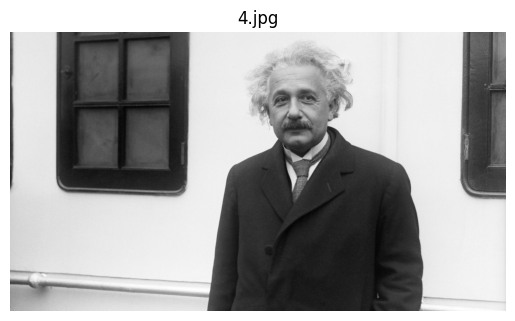

In [5]:
image_path = os.path.join(positive_dir_path, '4.jpg')
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.title('4.jpg')
plt.show()

## 📷 Capture your own face (optional)

You can run this workshop with your own images. Go to https://webcamtests.com/take-photo, capture and store 5 images with your face visible. Move the files into the `face_images/positive_user` folder and keep the filenames unchanged (`Photo-1.jpeg` to `Photo-5.jpeg`).

In [6]:
user_dir = Path(cwd) / "face_images" / "positive_user"
expected_user_files = [f"Photo-{i}.jpeg" for i in range(1, 6)]

def files_match(path: Path) -> bool:
    """Return True if directory contains exactly the expected five files."""
    return sorted(
        f.name for f in path.glob("*") if f.suffix.lower() in (".jpg", ".jpeg", ".png")
    ) == expected_user_files

if user_dir.exists() and files_match(user_dir):
    # Check every image for a detectable face
    problematic = []
    for fname in expected_user_files:
        img_path = user_dir / fname
        img = face_recognition.load_image_file(str(img_path))
        if not face_recognition.face_encodings(img):
            problematic.append(fname)

    if not problematic:
        positive_dir_path = str(user_dir)  # 🔄 override
        print("✅  Using your five photos as the positive class.")
    else:
        print(
            "⚠️  Custom images found, but no face encodings detected in:\n"
            + "\n".join(f"  • {fn}" for fn in problematic)
            + "\nFalling back to Einstein set."
        )
else:
    print("ℹ️  No valid custom image set detected – using Einstein photos.")

ℹ️  No valid custom image set detected – using Einstein photos.


## 📂 Load the dataset and extract the features

We will load the dataset, extract the features, and take a look at the images.

In [7]:
def iter_face_embeddings(directory: Path, label: int):
    """
    Yields dicts with keys:
      - 'filename': str
      - 'label':    int (1=positive, 0=negative)
      - 'embedding': np.ndarray shape (128,)
    """
    for img_path in sorted(directory.iterdir()):
        if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png'}:
            continue
        image = face_recognition.load_image_file(str(img_path))
        encs = face_recognition.face_encodings(image)
        if not encs:
            print(f"[warn] no face in {img_path.name}, skipping")
            continue
        yield {
            'filename': img_path.name,
            'label': label,
            'embedding': encs[0]
        }

In [8]:
# also define negative_dir_path
negative_dir_path = os.path.join(cwd, 'face_images', 'negative')

# collect records
records = list(iter_face_embeddings(Path(positive_dir_path), label=1)) \
        + list(iter_face_embeddings(Path(negative_dir_path), label=0))

# DataFrame with metadata + raw embeddings
df = pd.DataFrame(records)

# stack embeddings into an (n_samples × 128) array
X = np.stack(df['embedding'].values)
y = df['label'].values

In [9]:
df.head(10)

,filename,label,embedding
0,1.jpg,1,"[-0.13916254043579102, 0.06765440106391907, 0...."
1,2.jpg,1,"[-0.10024195909500122, 0.060482949018478394, 0..."
2,3.jpg,1,"[-0.11690331250429153, -0.0040309554897248745,..."
3,4.jpg,1,"[-0.1615755558013916, 0.07210954278707504, 0.0..."
4,5.jpg,1,"[-0.057057902216911316, 0.01846969872713089, 0..."
5,12_0_0_20170110215739155.jpg,0,"[-0.0820397362112999, 0.027357343584299088, 0...."
6,14_0_1_20170117141604244.jpg,0,"[-0.21727801859378815, 0.1069168969988823, 0.0..."
7,14_1_3_20170104013523266.jpg,0,"[-0.19818995893001556, 0.016170527786016464, 0..."
8,15_0_0_20170110225440579.jpg,0,"[-0.10357315838336945, 0.09260284155607224, 0...."
9,17_1_4_20170104001810179.jpg,0,"[-0.10423953086137772, 0.1865963637828827, 0.0..."


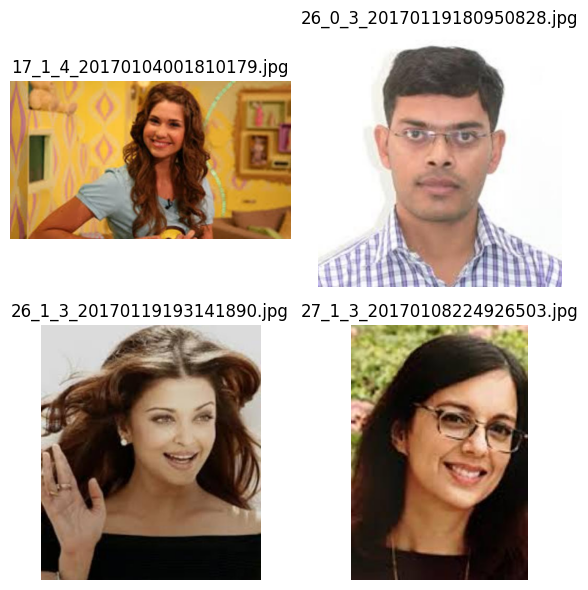

In [10]:
indices = [9, 24, 29, 32]

# Fetch those filenames
filenames = df.loc[indices, 'filename'].tolist()

# create a 2×2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(6, 6))

for ax, fname in zip(axes.flatten(), filenames):
    image_path = os.path.join(negative_dir_path, fname)
    img = Image.open(image_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(fname)

plt.tight_layout()
plt.show()

## ✂️ Split into a training and test dataset

We will split the dataset into a training and test dataset and take a look at both.

In [11]:
# 1) Positive class: first three → train, last two → test
df_pos = df[df['label'] == 1].reset_index(drop=True)
train_pos = df_pos.iloc[[0, 1, 2]]
test_pos  = df_pos.iloc[[3, 4]]

# 2) Negative class: random 2/3 train, 1/3 test (seed=42)
df_neg = df[df['label'] == 0].reset_index(drop=True)
train_neg, test_neg = train_test_split(
    df_neg,
    test_size=1/3,
    random_state=42,
    shuffle=True
)

# 3) Combine back together
train_df = pd.concat([train_pos, train_neg]).reset_index(drop=True)
test_df  = pd.concat([test_pos,  test_neg]).reset_index(drop=True)

# 4) Extract X / y arrays
X_train = np.stack(train_df['embedding'].values)
y_train = train_df['label'].values

X_test  = np.stack(test_df['embedding'].values)
y_test  = test_df['label'].values

# 5) Quick sanity check
print(f"Training samples: {len(train_df)}  (pos={len(train_pos)}, neg={len(train_neg)})")
print(f" Testing samples: {len(test_df)}  (pos={len(test_pos)}, neg={len(test_neg)})")

Training samples: 68  (pos=3, neg=65)
 Testing samples: 35  (pos=2, neg=33)


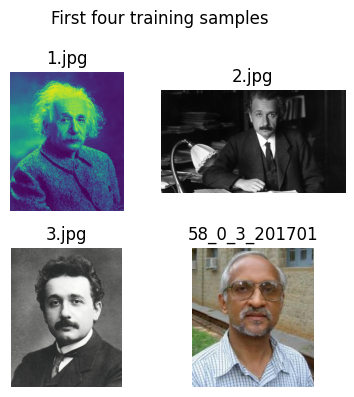

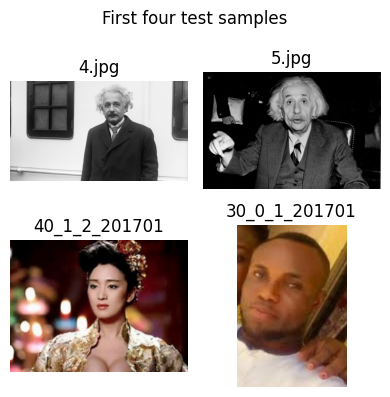

In [12]:
def _show_samples(df_subset, title):
    fig, axes = plt.subplots(2, 2, figsize=(4, 4))
    for ax, (_, row) in zip(axes.flat, df_subset.iterrows()):
        root = positive_dir_path if row["label"] == 1 else negative_dir_path
        img = Image.open(os.path.join(root, row["filename"]))
        ax.imshow(img); ax.axis("off"); ax.set_title(row["filename"][0:13])
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

_show_samples(train_df.iloc[:4], "First four training samples")
_show_samples(test_df.iloc[:4],  "First four test samples")

In [13]:
# 1) Initialize scaler
scaler = StandardScaler()

# 2) Fit on training data only, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 3) (Optional) check means/vars
print("Train mean (first 3 features):", X_train_scaled.mean(axis=0)[:3])
print("Train std  (first 3 features):", X_train_scaled.std(axis=0)[:3])

Train mean (first 3 features): [-5.36106086e-17  2.44902138e-18  1.95309455e-16]
Train std  (first 3 features): [1. 1. 1.]


## Train the model

In [14]:
clf_large = MLPClassifier(hidden_layer_sizes=(65,), max_iter=100, random_state=42)
clf_large.fit(X_train_scaled, y_train)

/Users/kp/dev/python-sdk2/zkml-research/kya_face/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(65,), max_iter=100, random_state=42)

## 📊 Evaluate the model

Train accuracy: 1.0
Test accuracy: 1.0


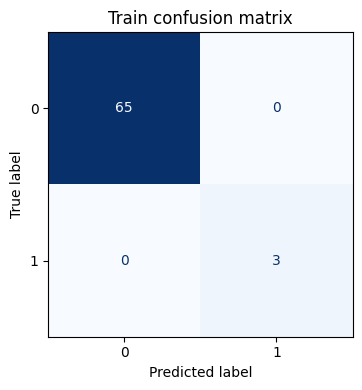

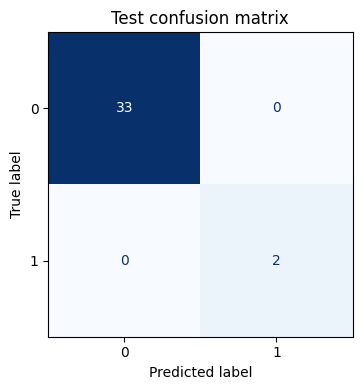

In [15]:
print("Train accuracy:", clf_large.score(X_train_scaled, y_train))
print("Test accuracy:", clf_large.score(X_test_scaled,  y_test))

y_train_pred_clf_large = clf_large.predict(X_train_scaled)
y_test_pred_clf_large  = clf_large.predict(X_test_scaled)

plot_confusion_matrix(y_train, y_train_pred_clf_large, title="Train confusion matrix")
plot_confusion_matrix(y_test,  y_test_pred_clf_large,  title="Test confusion matrix")

In [16]:
summarize_mlp(clf_large)

Layer sizes (including input and output): [128, 65, 1]
 ➔ Total layers (including input layer): 3
 ➔ Hidden layers: 1
 ➔ Output layer: 1
Total parameters: 8,451


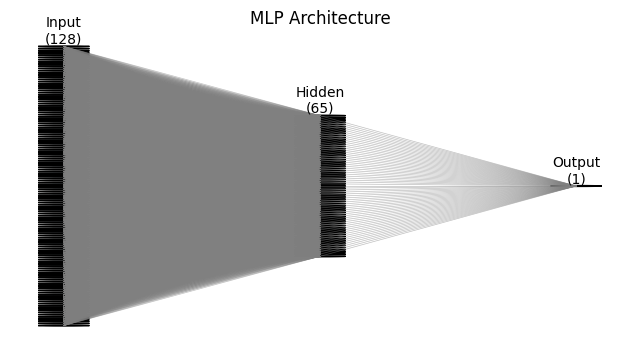

In [17]:
plot_mlp_architecture(clf_large)

## 🔄 PCA feature transformation

The model is too large - making proving slow, expensive or even infeasible. Can we get a smaller model while preserving predictive performance?
Let’s try reducing the feature space with PCA.

In [18]:
# Cell X: PCA dimensionality reduction
from sklearn.decomposition import PCA

# 1) Initialize PCA (fit only on training data)
pca = PCA(n_components=32, random_state=42)

# 2) Fit on X_train and transform both train & test
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

# 3) Check shapes to confirm reduction
print("X_train_pca shape:", X_train_pca.shape)  # (n_train_samples, 32)
print("X_test_pca  shape:", X_test_pca.shape)   # (n_test_samples, 32)

# (Optional) Examine how much variance is retained
explained = pca.explained_variance_ratio_.cumsum()
print("Total variance retained:", explained[-1])

X_train_pca shape: (68, 32)
X_test_pca  shape: (35, 32)
Total variance retained: 0.9265818393070243


In [19]:
# Cell Y: Re-standardize PCA outputs before model training
from sklearn.preprocessing import StandardScaler

# 1) Initialize a new scaler
scaler_pca = StandardScaler()

# 2) Fit on the PCA‐transformed training data, then apply to both
X_train_pca_scaled = scaler_pca.fit_transform(X_train_pca)
X_test_pca_scaled  = scaler_pca.transform(X_test_pca)

# 3) Quick sanity check: zero mean/unit var on train
print("Post-PCA train means (first 3 comps):", 
      X_train_pca_scaled.mean(axis=0)[:3])
print("Post-PCA train stds  (first 3 comps):", 
      X_train_pca_scaled.std(axis=0)[:3])

Post-PCA train means (first 3 comps): [3.42862993e-17 6.20418749e-17 6.53072367e-18]
Post-PCA train stds  (first 3 comps): [1. 1. 1.]


## 🔁 Re-train and evaluate the model

In [20]:
clf_small = MLPClassifier(hidden_layer_sizes=(17,), max_iter=100, random_state=42)
clf_small.fit(X_train_pca_scaled, y_train)

/Users/kp/dev/python-sdk2/zkml-research/kya_face/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(17,), max_iter=100, random_state=42)

Train accuracy: 1.0
Test accuracy: 1.0


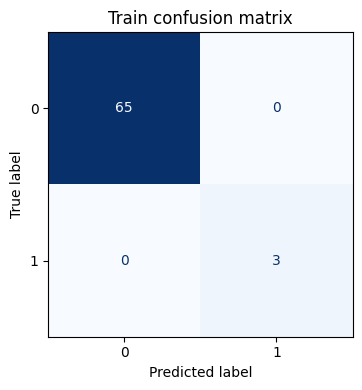

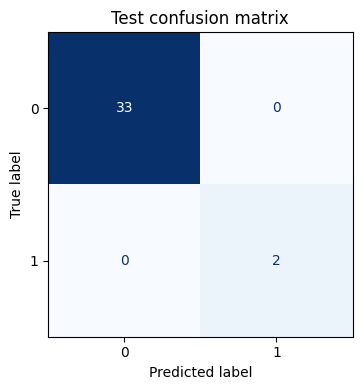

In [21]:
print("Train accuracy:", clf_small.score(X_train_pca_scaled, y_train))
print("Test accuracy:", clf_small.score(X_test_pca_scaled,  y_test))

y_train_pred_clf_small = clf_small.predict(X_train_pca_scaled)
y_test_pred_clf_small  = clf_small.predict(X_test_pca_scaled)

plot_confusion_matrix(y_train, y_train_pred_clf_small, title="Train confusion matrix")
plot_confusion_matrix(y_test,  y_test_pred_clf_small,  title="Test confusion matrix")

In [22]:
summarize_mlp(clf_small)

Layer sizes (including input and output): [32, 17, 1]
 ➔ Total layers (including input layer): 3
 ➔ Hidden layers: 1
 ➔ Output layer: 1
Total parameters: 579


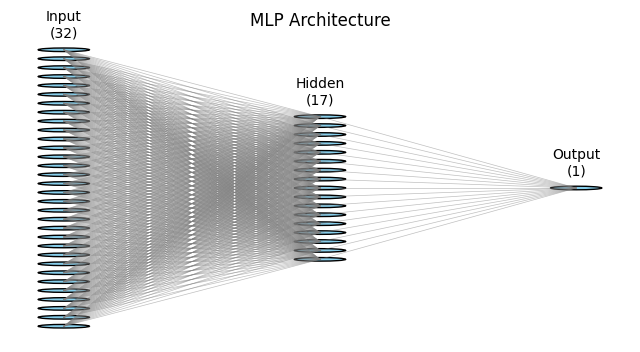

In [23]:
plot_mlp_architecture(clf_small)

Perfect! The new model still has an excellent predictive performance while being much smaller.

## ⚙️🦁 Transpile to Leo

Now let's transpile this smaller model into a Leo program. This will create a Leo project folder `workshop_kya_face_*` on your machine.

In [24]:
# Get a random number for the program name generation between 0 and 10000
random_number = random.randint(0, 10000)

# Create a unique project name using the random number
leo_project_name = f"workshop_kya_face_{random_number}"

# Set a fixed_point_scaling_factor of 16
fixed_point_scaling_factor = 16

# Transpile the NN into Leo code
lt = LeoTranspiler(
    model=clf_small
)
lt.to_leo(
    path=cwd, project_name=leo_project_name, fixed_point_scaling_factor=fixed_point_scaling_factor
)

Let's take a look at the transpiled Leo code.

In [25]:
leo_code_path = os.path.join(
    (os.path.join(cwd, leo_project_name, "src", "main.leo"))
)
with open(leo_code_path, "r") as f:
    leo_code = f.read()
print(leo_code)

// This file was automatically generated by the zkml LeoTranspiler.
program workshop_kya_face_8297.aleo {
    struct Struct0 {
  x0: i64,
  x1: i64
}
    transition main (struct0_0: Struct0, struct0_1: Struct0, struct0_2: Struct0, struct0_3: Struct0, struct0_4: Struct0, struct0_5: Struct0, struct0_6: Struct0, struct0_7: Struct0, struct0_8: Struct0, struct0_9: Struct0, struct0_10: Struct0, struct0_11: Struct0, struct0_12: Struct0, struct0_13: Struct0, struct0_14: Struct0, struct0_15: Struct0) -> (i64) {
        let neuron_1_0: i64 = relu(-3i64 * struct0_0.x0 + -1i64 * struct0_0.x1 + 7i64 * struct0_1.x0 + 1i64 * struct0_1.x1 + -6i64 * struct0_2.x0 + -1i64 * struct0_2.x1 + -3i64 * struct0_3.x0 + -1i64 * struct0_3.x1 + -1i64 * struct0_4.x0 + -1i64 * struct0_4.x1 + 2i64 * struct0_5.x0 + 2i64 * struct0_5.x1 + 2i64 * struct0_6.x0 + 2i64 * struct0_6.x1 + 3i64 * struct0_7.x0 + -1i64 * struct0_7.x1 + 3i64 * struct0_8.x0 + 3i64 * struct0_8.x1 + 2i64 * struct0_9.x0 + -4i64 * struct0_9.x1 + -1i64 *

Let's compare these numbers with parameters of the scikit-learn model. Specifically, compare the numbers below to the first weight of the first neuron (`neuron_1_0`) and to the bias at the far right of that neuron inside the Leo code - they should match.

In [26]:
w0 = clf_small.coefs_[0][0, 0]                 # first weight into first hidden neuron
b0 = clf_small.intercepts_[0][0]               # first bias of hidden layer

print(f"Float weight  w₀: {w0}")
print(f"Float bias    b₀: {b0}")

print(f"\nFixed-point representations (Leo expects ints):")
print(f"w₀ × {fixed_point_scaling_factor:<2}  = {w0 * fixed_point_scaling_factor :.6f}  →  {int(round(w0 * fixed_point_scaling_factor))}")
print(f"b₀ × {fixed_point_scaling_factor**2:<2}= {b0 * fixed_point_scaling_factor**2 :.6f}  →  {int(round(b0 * fixed_point_scaling_factor**2))}")

Float weight  w₀: -0.17370561879190466
Float bias    b₀: 0.1752743875380545

Fixed-point representations (Leo expects ints):
w₀ × 16  = -2.779290  →  -3
b₀ × 256= 44.870243  →  45


## ▶️ Test execution of the Leo program

Let's execute the Leo program a couple of times and compare the prediction to the Python scikit-learn predictions.

In [27]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [28]:
def show_image_and_predictions(test_index):
    test_features = X_test_pca_scaled[test_index:test_index+1]

    sample_meta = test_df.iloc[test_index]
    img_dir     = positive_dir_path if sample_meta['label'] == 1 else negative_dir_path
    image_path  = os.path.join(img_dir, sample_meta['filename'])

    # plot image
    img = Image.open(image_path)
    plt.figure(figsize=(3, 3))  
    plt.imshow(img)
    plt.axis('off')
    plt.title(sample_meta['filename'])
    plt.show()

    # sklearn’s probability
    python_probability_prediction = clf_small.predict_proba(test_features)
    print("Python computation results")
    print(f"\tProbabilities after sigmoid: {python_probability_prediction[0]}")
    print(f"\tPredicted class: {np.argmax(python_probability_prediction)}\n")

    # Leo computation
    leo_computation = lt.run(input=test_features[0])

    print("Leo computation results")
    print(f"\tConstraints: {leo_computation.circuit_constraints}")
    print(f"\tRuntime: {leo_computation.runtime} seconds")
    print(f"\tInput: {leo_computation.input}")
    print(f"\tRaw output: {leo_computation.output}")
    print(f"\tDecimal output: {leo_computation.output_decimal}")

    # Convert list → array for sigmoid
    decimal_array = np.array(leo_computation.output_decimal, dtype=float)
    p_pos = sigmoid(decimal_array[0])           # probability of class 1
    leo_probs = np.array([1 - p_pos, p_pos])
    print(f"\tProbabilities after sigmoid: {leo_probs.tolist()}")

    print(f"\tPredicted class: {np.argmax(leo_probs)}")

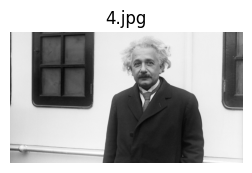

Python computation results
	Probabilities after sigmoid: [0.34037728 0.65962272]
	Predicted class: 1

Leo computation results
	Constraints: 261952
	Runtime: 1.7773780822753906 seconds
	Input: ['{ x0: 23i64, x1: 3i64 }', '{ x0: 15i64, x1: 19i64 }', '{ x0: -3i64, x1: -22i64 }', '{ x0: 4i64, x1: -1i64 }', '{ x0: 23i64, x1: -19i64 }', '{ x0: 13i64, x1: -23i64 }', '{ x0: 4i64, x1: -13i64 }', '{ x0: 2i64, x1: 2i64 }', '{ x0: 9i64, x1: -16i64 }', '{ x0: -2i64, x1: 14i64 }', '{ x0: 4i64, x1: 7i64 }', '{ x0: 12i64, x1: 0i64 }', '{ x0: -2i64, x1: 16i64 }', '{ x0: -6i64, x1: 0i64 }', '{ x0: -9i64, x1: -7i64 }', '{ x0: 17i64, x1: -4i64 }']
	Raw output: [2624]
	Decimal output: [0.640625]
	Probabilities after sigmoid: [0.34510527095787247, 0.6548947290421275]
	Predicted class: 1


In [29]:
show_image_and_predictions(0)

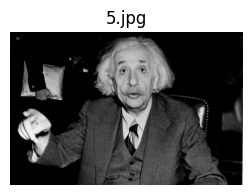

Python computation results
	Probabilities after sigmoid: [0.38794389 0.61205611]
	Predicted class: 1

Leo computation results
	Constraints: 261952
	Runtime: 1.6811797618865967 seconds
	Input: ['{ x0: 21i64, x1: 3i64 }', '{ x0: 12i64, x1: 22i64 }', '{ x0: -3i64, x1: -14i64 }', '{ x0: 7i64, x1: 7i64 }', '{ x0: 25i64, x1: -14i64 }', '{ x0: 22i64, x1: -15i64 }', '{ x0: 4i64, x1: 0i64 }', '{ x0: 2i64, x1: 2i64 }', '{ x0: 16i64, x1: 5i64 }', '{ x0: 3i64, x1: -1i64 }', '{ x0: 0i64, x1: 9i64 }', '{ x0: -18i64, x1: 8i64 }', '{ x0: 14i64, x1: 25i64 }', '{ x0: -11i64, x1: 2i64 }', '{ x0: -35i64, x1: 3i64 }', '{ x0: -30i64, x1: 0i64 }']
	Raw output: [1154]
	Decimal output: [0.28173828125]
	Probabilities after sigmoid: [0.43002766487393085, 0.5699723351260692]
	Predicted class: 1


In [30]:
show_image_and_predictions(1)

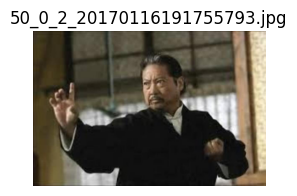

Python computation results
	Probabilities after sigmoid: [0.76026156 0.23973844]
	Predicted class: 0

Leo computation results
	Constraints: 261952
	Runtime: 1.6764061450958252 seconds
	Input: ['{ x0: 2i64, x1: -3i64 }', '{ x0: 25i64, x1: 8i64 }', '{ x0: 14i64, x1: 18i64 }', '{ x0: 33i64, x1: 1i64 }', '{ x0: -3i64, x1: 10i64 }', '{ x0: 0i64, x1: 1i64 }', '{ x0: 3i64, x1: -7i64 }', '{ x0: 9i64, x1: -11i64 }', '{ x0: 17i64, x1: 20i64 }', '{ x0: -1i64, x1: 19i64 }', '{ x0: -24i64, x1: 5i64 }', '{ x0: 17i64, x1: 18i64 }', '{ x0: -6i64, x1: 4i64 }', '{ x0: 6i64, x1: -11i64 }', '{ x0: -13i64, x1: -11i64 }', '{ x0: 12i64, x1: -37i64 }']
	Raw output: [-4471]
	Decimal output: [-1.091552734375]
	Probabilities after sigmoid: [0.7486739988327564, 0.25132600116724363]
	Predicted class: 0


In [31]:
show_image_and_predictions(13)

Note: small deviations in the probabilities between the Python and the Leo variant come from the fixed point number representation.

## 🚀 Deploy the Leo program

In [32]:
print(os.path.join(cwd, leo_project_name))

/Users/kp/dev/python-sdk2/zkml-research/kya_face/workshop_kya_face_8297


Open the directory above, update the private key with a funded one in the `.env` file and run `leo deploy --broadcast`. Then, check for the transaction to land in the [Provable testnet explorer](https://testnet.explorer.provable.com/).

## 💡 Extension ideas
### Machine Learning
* Add data augmentation
* Add early stopping and validation approach in training
* Explore data quantization and other ML models
* ...

### Zero Knowledge
* ML model parameters as private inputs (so no one can steal your model)
* Hash model parameters to commit to an identity
* Store result on-chain
* ...

Check out the [Provable KYA app](https://kya.provable.com/) where most of these ideas are already implemented, and the training is done entirely locally in your browser!

## 🗣️ Discussion
We are interested in a broad discussion with you, including the following aspects:
* Applications
* Security
* Technical improvements
* ...

## 📚 Further resources
* MNIST example with [constraint optimization through model pruning](https://github.com/ProvableHQ/python-sdk/blob/master/zkml/examples/MLP_neural_networks/mnist_dataset.ipynb)
* [zkml with decision trees](https://github.com/ProvableHQ/python-sdk/blob/master/zkml/examples/decision_trees/iris_dataset.ipynb)
* [zkml transpiler](https://github.com/ProvableHQ/python-sdk/tree/master/zkml) - contributions welcome 🤝